# 📊 Heart Disease Visualisations

In this section, I explore the heart disease dataset using different visualisation techniques.
The goal is to understand relationships between medical features, identify patterns, and highlight factors that may influence heart disease risk.

I use Plotly Express, a powerful Python library for interactive visualisations.
It allows me to create scatter plots, histograms, boxplots, and animated charts that help reveal insights in the data.

## What I will visualise:
Distribution of key medical attributes (age, cholesterol, heart rate)

Relationships between variables (e.g., cholesterol vs max heart rate)

Differences between patient groups (e.g., chest pain type, sex, target)

Interactive charts to explore patterns more deeply


In [26]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression

Dataset used the cleaned dataset

This dataset contains:

- Numerical features (age, trestbps, chol, thalach, oldpeak)

- Categorical features (sex, cp, fbs, restecg, exang, slope, ca, thal)

- Target variable (presence of heart disease)

In [27]:
df = pd.read_csv("../data/heart_cleaned.csv")

### Distribution of Key Medical Attributes
To understand how the medical attributes are spread in the dataset, I visualise the distribution of age, cholesterol, and maximum heart rate (thalach). 

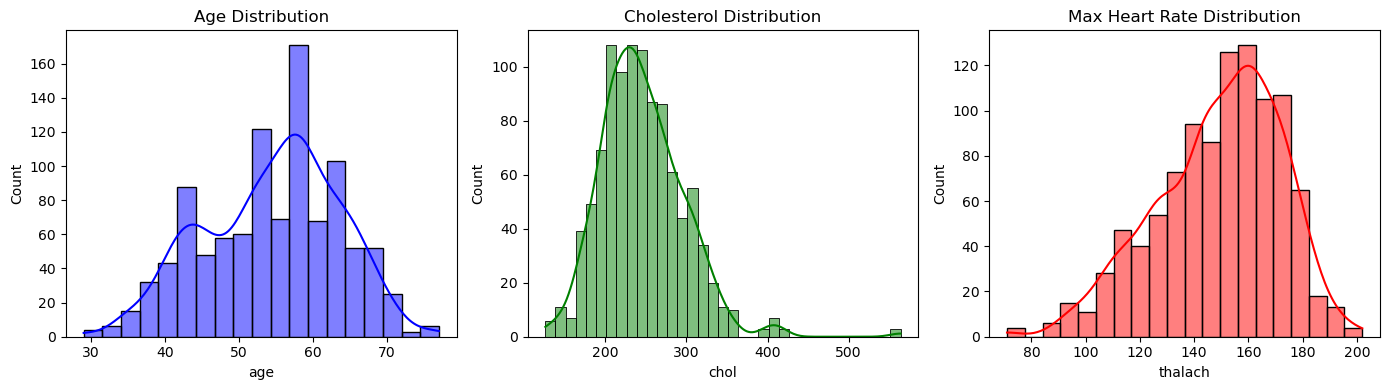

In [29]:
plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
sns.histplot(df["age"], kde=True, color="blue")
plt.title("Age Distribution")

plt.subplot(1,3,2)
sns.histplot(df["chol"], kde=True, color="green")
plt.title("Cholesterol Distribution")

plt.subplot(1,3,3)
sns.histplot(df["thalach"], kde=True, color="red")
plt.title("Max Heart Rate Distribution")

plt.tight_layout()
plt.show()

### Interpretation
Age: Most patients are between 50–60 years old, with fewer younger or older individuals.

Cholesterol: Values cluster around 200–300, but there are some high outliers above 400.

Max Heart Rate: The distribution peaks around 150–160, suggesting most patients reach similar maximum heart rates.

### Relationship Between Cholesterol and Max Heart Rate
To explore how medical attributes interact, I visualise the relationship between cholesterol (chol) and maximum heart rate (thalach). Scatter plots help identify trends, clusters, and potential correlations between variables.

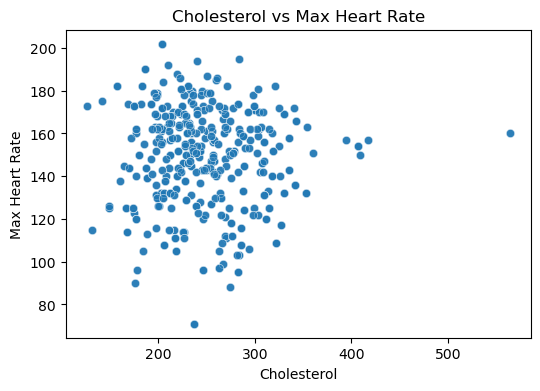

In [30]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["chol"], y=df["thalach"], alpha=0.6)
plt.title("Cholesterol vs Max Heart Rate")
plt.xlabel("Cholesterol")
plt.ylabel("Max Heart Rate")
plt.show()

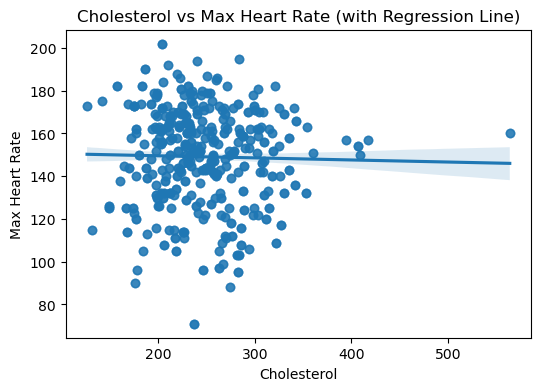

In [31]:
plt.figure(figsize=(6,4))
sns.regplot(x=df["chol"], y=df["thalach"], scatter_kws={'alpha':0.5})
plt.title("Cholesterol vs Max Heart Rate (with Regression Line)")
plt.xlabel("Cholesterol")
plt.ylabel("Max Heart Rate")
plt.show()


In [32]:
X = df[["chol"]]
y = df["thalach"]

model = LinearRegression()
model.fit(X, y)

print("Slope:", model.coef_[0])

Slope: -0.009708438659118671


The regression line is nearly horizontal, indicating a very weak or no linear relationship between cholesterol and maximum heart rate. This means cholesterol is not a strong predictor of max heart rate in this dataset. The slope of the regression line is almost zero, which tells us that when cholesterol increases, maximum heart rate does not consistently increase or decrease. In other words, there is almost no linear relationship between these two variables.

The dataset contains 14 variables, and a full pairplot would generate 196 plots, which is too large and difficult to interpret. Instead, I selected a small group of important features to create a clear and readable pairplot.

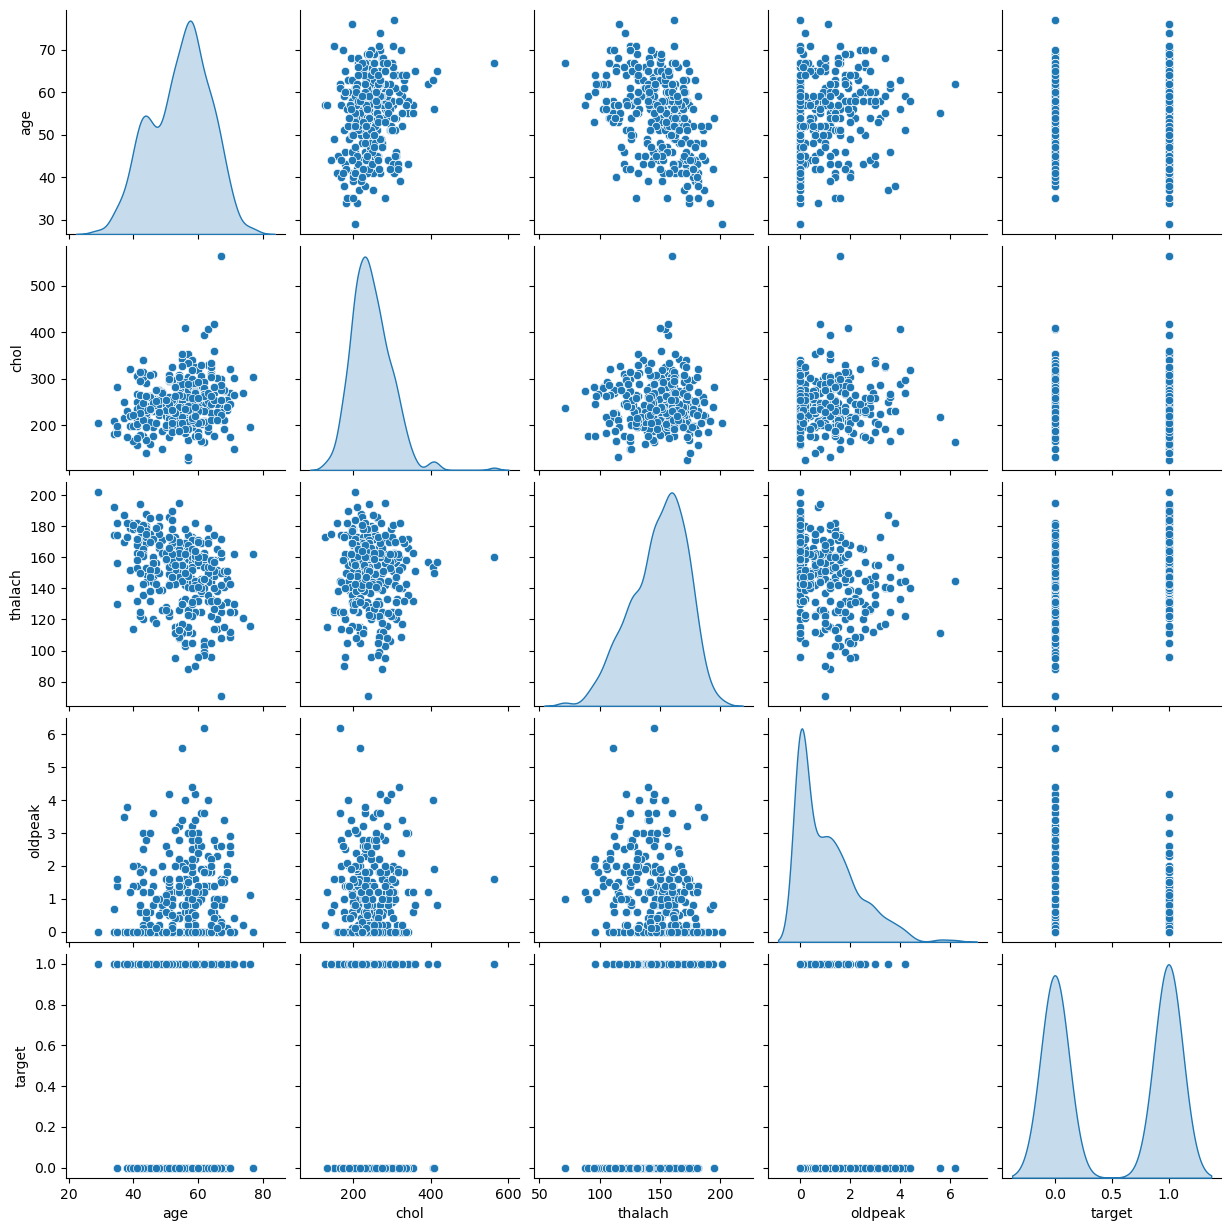

In [35]:
sns.pairplot(df[["age", "chol", "thalach", "oldpeak", "target"]], diag_kind="kde")

The pairplot helps visualize how the key medical attributes relate to each other and to the heart‑disease target variable.

### Age
The distribution shows most patients are between 40–65 years old.

There is a visible downward trend between age and thalach (max heart rate):
older patients tend to have lower maximum heart rate, which is medically expected.

### Cholesterol (chol)
Cholesterol values vary widely, with many patients between 200–300 mg/dl.

The scatterplots show no clear relationship between cholesterol and other variables.
This supports earlier finding: cholesterol is not a strong predictor in this dataset.

### Max Heart Rate (thalach)
Thalach has a wide distribution, with many values around 140–170.

It shows a negative relationship with age and a weak relationship with oldpeak.

Patients with lower thalach often appear in the group with target = 1 (heart disease).

### Oldpeak
Oldpeak values are mostly low, but higher values appear more often in patients with target = 1.

This suggests oldpeak is an important predictor of heart disease.

### Target (heart disease)
Scatterplots show that:

Higher oldpeak is associated with target = 1

Lower thalach is associated with target = 1

Age has a mild positive relationship with target

Cholesterol shows almost no separation between target groups
### Overall insight
The pairplot reveals that:

- thalach, oldpeak, and age show meaningful patterns related to heart disease

- cholesterol does not show a strong relationship with any variable

These insights help identify which features are useful for regression or classification models

## Correlation Heatmap

A correlation heatmap helps identify relationships between numerical features in the Heart Disease dataset.

It shows how strongly each pair of variables is related, using values between -1 and 1:

1.0 → perfect positive correlation

-1.0 → perfect negative correlation

0 → no correlation

This visualisation helps highlight which medical attributes may influence heart disease risk.

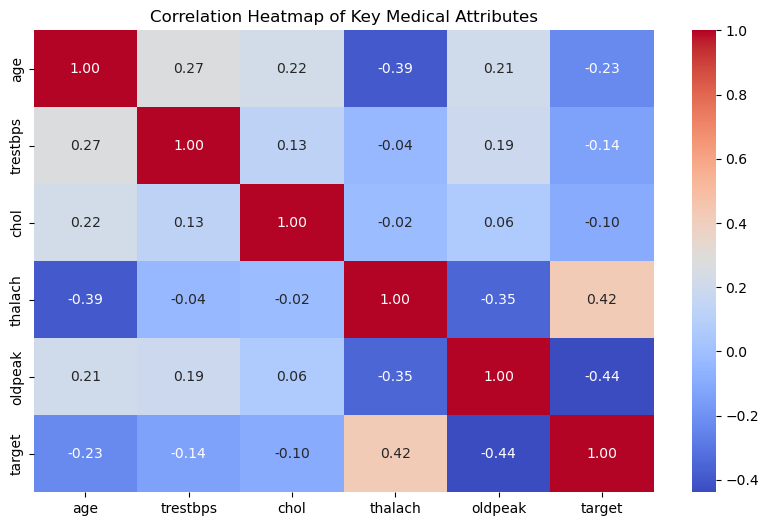

In [37]:
corr_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "target"]

plt.figure(figsize=(10,6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Key Medical Attributes")
plt.show()

### Age

- Age has a moderate negative correlation with thalach (−0.39).
This means older patients tend to have lower maximum heart rate, which is medically expected.

- Age has a weak negative correlation with target (−0.23).
Older patients are slightly more likely to have heart disease, but the relationship is not very strong.

### Resting Blood Pressure (trestbps)

- Shows weak correlations with all variables.
- It does not strongly predict heart disease.

### Cholesterol (chol)

- Cholesterol has very weak correlations with everything (all values near 0).

Cholesterol is not a meaningful predictor of heart disease or max heart rate.

### Max Heart Rate (thalach)

- Thalach has a positive correlation with target (0.42).
Patients with higher max heart rate are more likely to be target = 1 (heart disease).

- Thalach has a negative correlation with oldpeak (−0.35).

### Oldpeak

- Oldpeak has the strongest correlation with target (−0.44).
This makes oldpeak one of the most important features in the dataset.

### Overall Insight

1. Oldpeak, thalach, and age show the strongest relationships with heart disease.
2. Cholesterol and resting blood pressure show very weak correlations and are not useful predictors.
3. The heatmap helps identify which features should be prioritized in modeling and which can be ignored.



This scatter plot visualises how maximum heart rate (thalach) changes with age, with each point representing a patient. The color of each point indicates the heart disease target value, allowing us to compare patterns between individuals with and without heart disease.

Key patterns visible in the plot
There is a clear downward trend:
Younger patients generally achieve higher maximum heart rates, while older patients show lower values.
This is a normal physiological pattern and makes the relationship meaningful.

The color distribution shows that patients with heart disease (target = 1) often appear in the lower thalach range, especially at older ages.

Patients without heart disease (target = 0) tend to cluster around higher thalach values, even across different ages.

The separation between the two target groups becomes more noticeable as age increases, suggesting that age combined with thalach is a useful indicator for identifying heart‑disease risk.

Why this visualisation is effective
Compared to cholesterol vs max heart rate, this plot shows a stronger and medically supported relationship. The downward pattern is clear, the color separation is meaningful, and the variables interact in a way that helps with both exploratory analysis and model building.

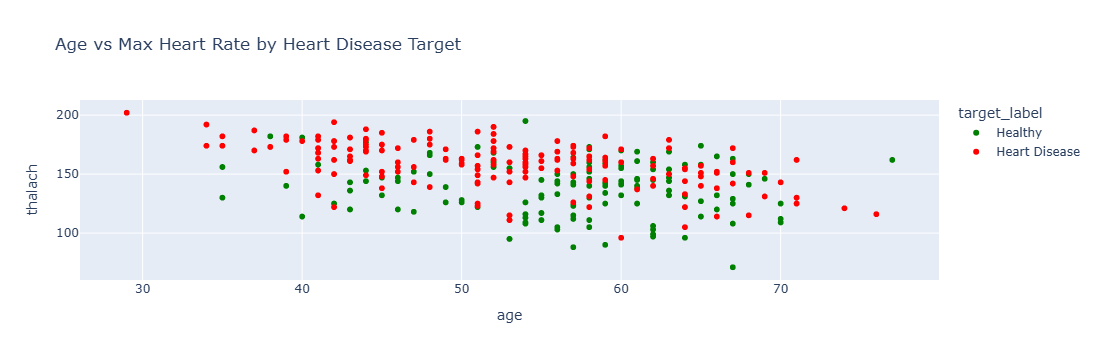

In [49]:
df["target_label"] = df["target"].map({"0": "Healthy", "1": "Heart Disease"})

fig = px.scatter(
    df,
    x="age",
    y="thalach",
    color="target_label",
    hover_name="age",
    title="Age vs Max Heart Rate by Heart Disease Target",
    color_discrete_map={
        "Healthy": "green",
        "Heart Disease": "red"
    }
)

fig.show()

### Distribution of Max Heart Rate by Heart Disease Target

This interactive histogram compares how maximum heart rate (thalach) is distributed among patients with and without heart disease. The chart uses color to separate the two groups:

Green → No heart disease (target = 0)

Red → Heart disease present (target = 1)

### Key observations

- Patients without heart disease tend to have higher maximum heart rate values, with a noticeable concentration in the upper range.

- Patients with heart disease show a wider spread but generally cluster around lower thalach values.

- The overlapping distributions make it easy to visually compare both groups and identify patterns related to heart‑disease risk.

This interactive view allows deeper exploration by hovering over bars to see exact counts and ranges.


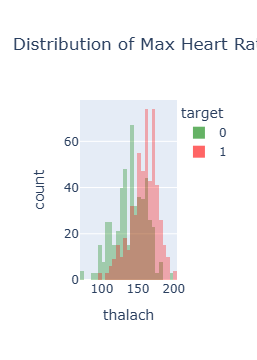

In [51]:
fig = px.histogram(
    df,
    x="thalach",
    color="target",
    barmode="overlay",
    title="Distribution of Max Heart Rate by Heart Disease Target",
    color_discrete_map={"0": "green", "1": "red"}
)

fig.update_traces(opacity=0.6)
fig.show()

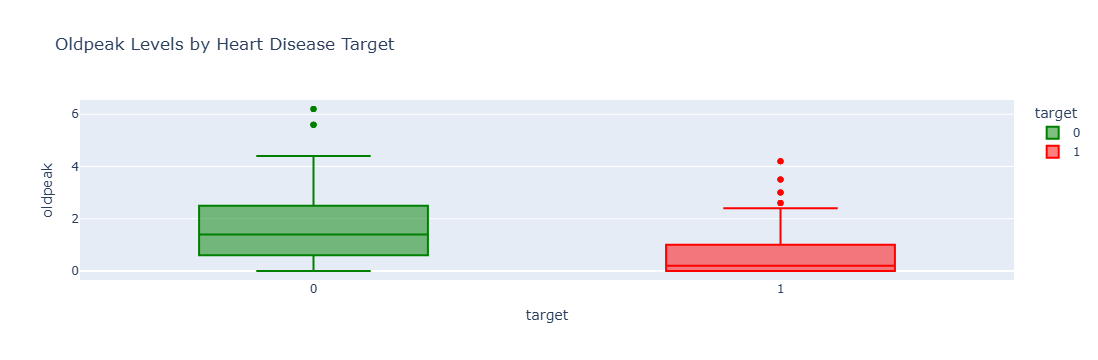

In [52]:
fig = px.box(
    df,
    x="target",
    y="oldpeak",
    color="target",
    title="Oldpeak Levels by Heart Disease Target",
    color_discrete_map={"0": "green", "1": "red"}
)

fig.show()